# Test labeler performance for BLIP1 and microsoft-gpt

In [86]:
# load the test dataset for image captioner
from datasets import load_dataset
ds = load_dataset("nlphuji/flickr30k",split='test')

In [8]:
# check the datasets
ds

Dataset({
    features: ['image', 'caption', 'sentids', 'split', 'img_id', 'filename'],
    num_rows: 31014
})

## Test BLIP1: In this part, I'll show some examples for getting the image captioning for target event photo and images in flickr30k and how to use BLEU and meteor to evaluate the performance of image captioner

In [95]:
from PIL import Image
import requests
from transformers import BlipProcessor, BlipForConditionalGeneration

# example code to generate the image caption
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

image_path = r'C:\Users\16171\Desktop\ECSE552final_project\PETA-main\PETA-main\albums\Personal_sports\44_65592177@N00\339888948.jpg';
image = Image.open(image_path).convert("RGB")
text = "A picture of"
inputs = processor(images=image, text=text, return_tensors="pt")

generated_ids = model.generate(**inputs, max_length=50)
generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
print("Generated Text:", generated_text)

Generated Text: a picture of a skateboarder doing a trick


In [5]:
import nltk
nltk.download('wordnet') # nessesary for meteor_score

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\16171\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=500x374 at 0x141DE711FC0>, 'caption': ['Several men in hard hats are operating a giant pulley system.', 'Workers look down from up above on a piece of equipment.', 'Two men working on a machine wearing hard hats.', 'Four men on top of a tall structure.', 'Three men on a large rig.'], 'sentids': ['5', '6', '7', '8', '9'], 'split': 'train', 'img_id': '1', 'filename': '10002456.jpg'}


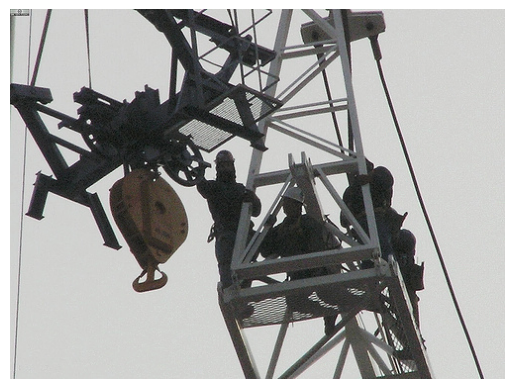

[['Several', 'men', 'in', 'hard', 'hats', 'are', 'operating', 'a', 'giant', 'pulley', 'system.'], ['Workers', 'look', 'down', 'from', 'up', 'above', 'on', 'a', 'piece', 'of', 'equipment.'], ['Two', 'men', 'working', 'on', 'a', 'machine', 'wearing', 'hard', 'hats.'], ['Four', 'men', 'on', 'top', 'of', 'a', 'tall', 'structure.'], ['Three', 'men', 'on', 'a', 'large', 'rig.']]
['the', 'picture', 'shows', 'a', 'man', 'on', 'a', 'crane']
BLEU-1 Score for the third sample: 0.2500
METEOR Score: 0.3024


In [97]:
import matplotlib.pyplot as plt
from nltk.translate.meteor_score import meteor_score
from nltk.translate.bleu_score import sentence_bleu
# Test evaluation metrics for the third sample in the dataset
sample = ds[1] 
print(sample)

# Get the image and display it
image = sample["image"]
plt.imshow(image)
plt.axis('off')  
plt.show()

# Process reference captions
reference_captions_split = [caption.split() if isinstance(caption, str) else caption 
                            for caption in sample["caption"]]
print(reference_captions_split) 

# Generate the predicted caption (assuming 'processor' and 'model' are predefined)
text = "The picture shows "
inputs = processor(images=image, text=text, return_tensors="pt")
generated_ids = model.generate(**inputs, max_length=50)
predicted_caption = processor.decode(generated_ids[0], skip_special_tokens=True)
predicted_caption_split = predicted_caption.split()
print(predicted_caption_split)

# Calculate the BLEU-1 score
bleu1 = sentence_bleu(reference_captions_split, predicted_caption_split,
                      weights=(1, 0, 0, 0))

# Calculate the METEOR score
meteor = meteor_score(reference_captions_split, predicted_caption_split)
# Print the evaluation results
print(f"BLEU-1 Score for the third sample: {bleu1:.4f}")
print(f"METEOR Score: {meteor:.4f}")


### Get results for flickr30k

In [ ]:
import csv
import json
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score  # Import meteor_score

# Create a list to store the results
results = []

# Initialize variables to compute averages
total_bleu1 = 0
total_bleu2 = 0
total_bleu3 = 0
total_bleu4 = 0
total_meteor = 0

# Iterate over the dataset
for sample in ds:
    # Get the image and captions from the sample
    image = sample["image"]
    reference_captions_split = [caption.split() if isinstance(caption, str) else caption 
                                for caption in sample["caption"]]

    # Generate the predicted caption
    generated_ids = model.generate(**inputs, max_length=50)
    predicted_caption = processor.decode(out[0], skip_special_tokens=True)

    # Split the predicted caption into words
    predicted_caption_split = predicted_caption.split()

    # Calculate BLEU scores (1-gram, 2-gram, 3-gram, 4-gram)
    bleu1 = sentence_bleu(reference_captions_split, predicted_caption_split, weights=(1, 0, 0, 0))
    bleu2 = sentence_bleu(reference_captions_split, predicted_caption_split, weights=(0, 1, 0, 0))
    bleu3 = sentence_bleu(reference_captions_split, predicted_caption_split, weights=(0, 0, 1, 0))
    bleu4 = sentence_bleu(reference_captions_split, predicted_caption_split, weights=(0.25, 0.25, 0.25, 0.25))

    # Calculate METEOR score
    meteor = meteor_score(reference_captions_split, predicted_caption_split)
    
    # Store the results in the list
    result = {
        "img_id": sample["img_id"],
        "reference_captions": ' '.join(reference_captions_split[0]),  # Assume 1st reference is representative
        "predicted_caption": ' '.join(predicted_caption_split),
        "bleu1": bleu1,
        "bleu2": bleu2,
        "bleu3": bleu3,
        "bleu4": bleu4,
        'meteor': meteor
    }
    
    results.append(result)

    # Add scores to the total for averaging
    total_bleu1 += bleu1
    total_bleu2 += bleu2
    total_bleu3 += bleu3
    total_bleu4 += bleu4
    total_meteor += meteor

# Calculate the average scores
avg_bleu1 = total_bleu1 / len(results)
avg_bleu2 = total_bleu2 / len(results)
avg_bleu3 = total_bleu3 / len(results)
avg_bleu4 = total_bleu4 / len(results)
avg_meteor = total_meteor / len(results)

# Print the average scores
print(f"Average BLEU-1: {avg_bleu1:.4f}")
print(f"Average BLEU-2: {avg_bleu2:.4f}")
print(f"Average BLEU-3: {avg_bleu3:.4f}")
print(f"Average BLEU-4: {avg_bleu4:.4f}")
print(f"Average METEOR: {avg_meteor:.4f}")

# Save the results to a JSON file
json_file_path = r"C:\Users\16171\Desktop\ECSE552final_project\flickr30kresults\blip_qs_bleu_scores_results.json"
with open(json_file_path, "w") as f:
    json.dump(results, f, indent=4)

# Save the results to a CSV file
csv_filename = r"C:\Users\16171\Desktop\ECSE552final_project\flickr30kresults\blip_qs_bleu_scores_results.csv"
with open(csv_filename, "w", newline="") as csvfile:
    fieldnames = ["img_id", "reference_captions", "predicted_caption", "bleu1", "bleu2", "bleu3", "bleu4", "meteor"]
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)

    writer.writeheader()  # Write header
    for result in results:
        writer.writerow(result)  # Write data rows

print(f"BLEU scores saved to '{csv_filename}' and '{json_file_path}'")

C:\ProgramData\anaconda3\envs\pytorchIntel\lib\site-packages\nltk\translate\bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)


## Get results for Microsoft-gpt

In [93]:
# Get the result for Microsoft-gpt
from transformers import AutoProcessor, AutoModelForCausalLM
from PIL import Image
import torch

# Load model and processor
model_name = "microsoft/git-base"
processor = AutoProcessor.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=500x374 at 0x141E90BFF40>, 'caption': ['Several men in hard hats are operating a giant pulley system.', 'Workers look down from up above on a piece of equipment.', 'Two men working on a machine wearing hard hats.', 'Four men on top of a tall structure.', 'Three men on a large rig.'], 'sentids': ['5', '6', '7', '8', '9'], 'split': 'train', 'img_id': '1', 'filename': '10002456.jpg'}


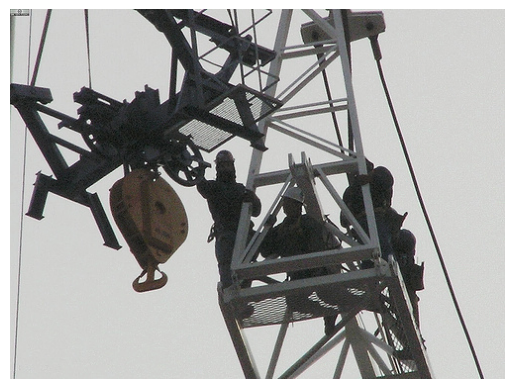

[['Several', 'men', 'in', 'hard', 'hats', 'are', 'operating', 'a', 'giant', 'pulley', 'system.'], ['Workers', 'look', 'down', 'from', 'up', 'above', 'on', 'a', 'piece', 'of', 'equipment.'], ['Two', 'men', 'working', 'on', 'a', 'machine', 'wearing', 'hard', 'hats.'], ['Four', 'men', 'on', 'top', 'of', 'a', 'tall', 'structure.'], ['Three', 'men', 'on', 'a', 'large', 'rig.']]
['a', 'metal', 'tower']
BLEU-1 Score for the third sample: 0.1226
METEOR Score: 0.0877


In [94]:
import matplotlib.pyplot as plt
from nltk.translate.meteor_score import meteor_score
from nltk.translate.bleu_score import sentence_bleu
# Test evaluation metrics for the third sample in the dataset
sample = ds[1] 
print(sample)

# Get the image and display it
image = sample["image"]
plt.imshow(image)
plt.axis('off')  
plt.show()

# Process reference captions
reference_captions_split = [caption.split() if isinstance(caption, str) else caption 
                            for caption in sample["caption"]]
print(reference_captions_split) 

inputs = processor(images=image, return_tensors="pt")
generated_ids = model.generate(**inputs, max_length=50)
predicted_caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
predicted_caption_split = predicted_caption.split()
print(predicted_caption_split)

# Calculate the BLEU-1 score
bleu1 = sentence_bleu(reference_captions_split, predicted_caption_split,
                      weights=(1, 0, 0, 0))

# Calculate the METEOR score
meteor = meteor_score(reference_captions_split, predicted_caption_split)
# Print the evaluation results
print(f"BLEU-1 Score for the third sample: {bleu1:.4f}")
print(f"METEOR Score: {meteor:.4f}")


In [3]:
import csv
import json
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score  # Import meteor_score

# Create a list to store the results
results = []

# Initialize variables to compute averages
total_bleu1 = 0
total_bleu2 = 0
total_bleu3 = 0
total_bleu4 = 0
total_meteor = 0

# Iterate over the dataset
for sample in ds:
    # Get the image and captions from the sample
    image = sample["image"]
    reference_captions_split = [caption.split() if isinstance(caption, str) else caption 
                                for caption in sample["caption"]]
    
    # Prepare the input text for the model
    inputs = processor(images=image,  return_tensors="pt")

    # Generate the predicted caption
    generated_ids = model.generate(**inputs, max_length=50)
    predicted_caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

    # Split the predicted caption into words
    predicted_caption_split = predicted_caption.split()

    # Calculate BLEU scores (1-gram, 2-gram, 3-gram, 4-gram)
    bleu1 = sentence_bleu(reference_captions_split, predicted_caption_split, weights=(1, 0, 0, 0))
    bleu2 = sentence_bleu(reference_captions_split, predicted_caption_split, weights=(0, 1, 0, 0))
    bleu3 = sentence_bleu(reference_captions_split, predicted_caption_split, weights=(0, 0, 1, 0))
    bleu4 = sentence_bleu(reference_captions_split, predicted_caption_split, weights=(0.25, 0.25, 0.25, 0.25))

    # Calculate METEOR score
    meteor = meteor_score(reference_captions_split, predicted_caption_split)
    
    # Store the results in the list
    result = {
        "img_id": sample["img_id"],
        "reference_captions": ' '.join(reference_captions_split[0]),  # Assume 1st reference is representative
        "predicted_caption": ' '.join(predicted_caption_split),
        "bleu1": bleu1,
        "bleu2": bleu2,
        "bleu3": bleu3,
        "bleu4": bleu4,
        'meteor': meteor
    }
    
    results.append(result)

    # Add scores to the total for averaging
    total_bleu1 += bleu1
    total_bleu2 += bleu2
    total_bleu3 += bleu3
    total_bleu4 += bleu4
    total_meteor += meteor

# Calculate the average scores
avg_bleu1 = total_bleu1 / len(results)
avg_bleu2 = total_bleu2 / len(results)
avg_bleu3 = total_bleu3 / len(results)
avg_bleu4 = total_bleu4 / len(results)
avg_meteor = total_meteor / len(results)

# Print the average scores
print(f"Average BLEU-1: {avg_bleu1:.4f}")
print(f"Average BLEU-2: {avg_bleu2:.4f}")
print(f"Average BLEU-3: {avg_bleu3:.4f}")
print(f"Average BLEU-4: {avg_bleu4:.4f}")
print(f"Average METEOR: {avg_meteor:.4f}")

# Save the results to a JSON file
json_file_path = r"C:\Users\16171\Desktop\ECSE552final_project\flickr30kresults\MSgpt_bleu_scores_results.json"
with open(json_file_path, "w") as f:
    json.dump(results, f, indent=4)

# Save the results to a CSV file
csv_filename = r"C:\Users\16171\Desktop\ECSE552final_project\flickr30kresults\MSgpt_bleu_scores_results.csv"
with open(csv_filename, "w", newline="") as csvfile:
    fieldnames = ["img_id", "reference_captions", "predicted_caption", "bleu1", "bleu2", "bleu3", "bleu4", "meteor"]
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)

    writer.writeheader()  # Write header
    for result in results:
        writer.writerow(result)  # Write data rows

print(f"BLEU scores saved to '{csv_filename}' and '{json_file_path}'")

C:\ProgramData\anaconda3\envs\pytorchIntel\lib\site-packages\nltk\translate\bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
C:\ProgramData\anaconda3\envs\pytorchIntel\lib\site-packages\nltk\translate\bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
C:\ProgramData\anaconda3\envs\pytorchIntel\lib\site-packages\nltk\translate\bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using 

Average BLEU-1: 0.4275
Average BLEU-2: 0.1693
Average BLEU-3: 0.0729
Average BLEU-4: 0.0377
Average METEOR: 0.2502
BLEU scores saved to 'C:\Users\16171\Desktop\ECSE552final_project\flickr30kresults\MSgpt_bleu_scores_results.csv' and 'C:\Users\16171\Desktop\ECSE552final_project\flickr30kresults\MSgpt_bleu_scores_results.json'


# In this part, we're getting the image embedding and sequence hidden state for an example photo

In [71]:
import requests
from PIL import Image
from transformers import BlipProcessor, BlipForConditionalGeneration
import torch

# Load BLIP processor and model
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

# Load and preprocess the image
image_path = r'C:\Users\16171\Desktop\ECSE552final_project\PETA-main\PETA-main\albums\Personal_sports\44_65592177@N00\339888948.jpg'
raw_image = Image.open(image_path).convert("RGB")  # Convert image to RGB mode

# Preprocess the image for the model
inputs = processor(raw_image, return_tensors="pt")
pixel_values = inputs["pixel_values"]  # Extract pixel values for the image

# Extract image embeddings using only the image encoder (Vision Transformer)
with torch.no_grad():  
    vision_outputs = model.vision_model(pixel_values=pixel_values)
# obtain image embedding with CLS token
hidden_states = vision_outputs.last_hidden_state
print(hidden_states)  
image_embedding = hidden_states[:, 0, :]
print("Image Embedding Shape:", image_embedding.shape)  

# Generate text from the image
out = model.generate(**inputs, max_length=50)  
print(processor.decode(out[0], skip_special_tokens=True,return_dict_in_generate=True))  
print(out)

tensor([[[-0.2850,  0.3562,  0.1814,  ...,  0.6003,  0.5563, -0.0318],
         [-0.4919,  0.6227, -0.9873,  ...,  0.5873,  0.4894,  0.0743],
         [-0.5349,  0.6945, -0.8461,  ...,  0.6536,  0.6085, -0.0403],
         ...,
         [-1.2518,  1.1302, -0.3802,  ..., -1.0244,  1.0900,  0.3469],
         [-0.4146,  0.1344, -0.5338,  ..., -0.6683,  1.0072,  0.6988],
         [-0.6796,  0.1721, -0.8028,  ..., -0.5537,  0.9490,  0.6676]]])
Image Embedding Shape: torch.Size([1, 768])
a boy on a skateboard
tensor([[30522,  1037,  2879,  2006,  1037, 17260,  6277,   102]])


In [78]:
# Generate image caption using the full BLIP model and hidden state
out = model.generate(**inputs, max_length=50,output_hidden_states=True,return_dict_in_generate=True)  # Generate text from the image
# Access the hidden states
hidden_states = out.hidden_states
print("Number of hidden states:", len(hidden_states))

# Get the last hidden state (e.g., from the last layer of the decoder)
last_hidden_state = hidden_states[-1]  # Last layer's hidden states
print("Type of last hidden state:", type(last_hidden_state))

# The hidden state is a tuple: (tensor, attention_weights)
# Access the tensor part of the last hidden state
hidden_state_tensor = last_hidden_state[0]
print("Shape of last hidden state tensor:", hidden_state_tensor.shape)

# Print the hidden state tensor of the last layer
print("Last hidden state tensor:", hidden_state_tensor)

# Decode the generated caption
generated_caption = processor.decode(out.sequences[0], skip_special_tokens=True)
print("Generated Caption:", generated_caption)

Number of hidden states: 7
Type of last hidden state: <class 'tuple'>
Shape of last hidden state tensor: torch.Size([1, 1, 768])
Last hidden state tensor: tensor([[[ 4.6756e-01, -5.1766e-01, -3.1157e-01,  2.5655e-01,  9.5640e-02,
          -4.7304e-01,  2.7700e-01, -4.1909e-02, -1.7550e-01, -2.9062e-01,
          -5.4648e-01, -8.1097e-01,  3.3385e-02,  2.6403e-01,  1.0691e-03,
           1.3566e-01, -5.9783e-01, -3.7254e-01,  1.6870e-01,  5.8147e-02,
           3.9268e-01,  4.4612e-01,  5.2089e-02,  1.2188e-01, -5.2068e-01,
           4.8478e-01, -4.5815e-01,  7.6034e-02, -4.1922e-01, -3.1656e-01,
           5.8755e-01, -4.1141e-01, -5.3376e-01, -1.2329e+00,  1.8159e-01,
          -2.3222e-01,  2.3105e-01,  7.2652e-01, -2.9552e-01, -1.3680e-01,
           5.6058e-01,  3.8708e-02,  9.7129e-02,  4.2763e-01,  4.6173e-01,
           6.1965e-01, -2.3897e-01, -7.7522e-01, -3.0202e-01, -5.5345e-01,
           3.1824e-01,  5.3905e-01, -6.8489e-01, -5.0497e-01,  4.7736e-01,
          -6.8016e-0

Loading images...
Clustering with K-Means...


C:\ProgramData\anaconda3\envs\pytorchIntel\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Clustering accuracy: 82.59%
Clusters saved to clusters.txt


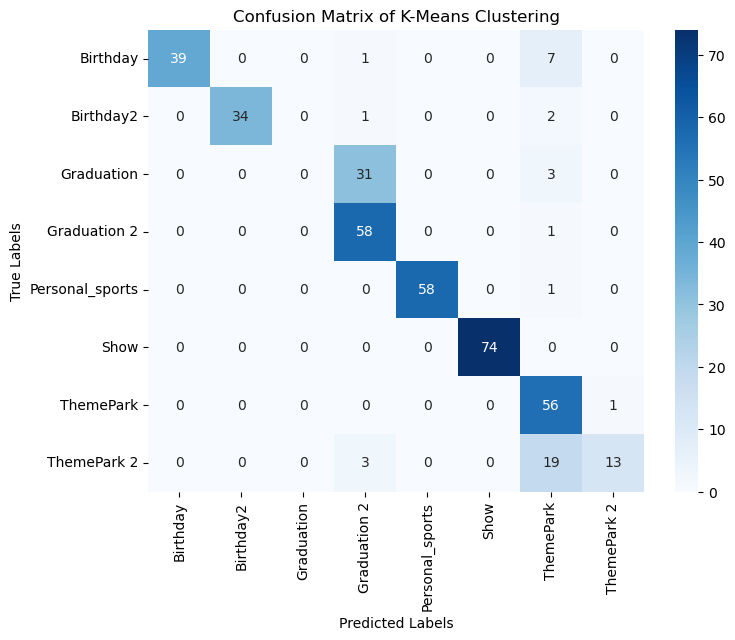

In [81]:
#This is simply test the image feature extractor for BLIP with cluster without fine-tune
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix
from collections import Counter
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import torch
from transformers import BlipProcessor, BlipForConditionalGeneration

# Initialize BLIP processor and model
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

# Function to load images from subfolders and preprocess them
def load_images_from_folder_get_blip_image_embedding(root_folder, image_size=(500 , 375)):
    """
    Loads images from subfolders, converts them to grayscale, resizes them,
    and flattens them into feature vectors.

    Parameters:
        root_folder (str): The path to the main folder containing subfolders of images.
        image_size (tuple): The fixed size to which images are resized.

    Returns:
        np.array: Image feature vectors.
        np.array: Corresponding labels.
        list: Names of subfolders (classes).
    """
    image_data = []  # Stores flattened pixel values of images
    labels = []  # Stores the numeric labels for each image
    label_names = []  # Stores the actual subfolder (category) names

    # Loop through subfolders (each representing a different category)
    for label, subfolder in enumerate(os.listdir(root_folder)):
        subfolder_path = os.path.join(root_folder, subfolder)
        if os.path.isdir(subfolder_path):
            label_names.append(subfolder)  # Store subfolder name as a label
            for file in os.listdir(subfolder_path):
                file_path = os.path.join(subfolder_path, file)
                try:
                    # Open image
                    with Image.open(file_path) as img:
                        img = img.convert("L")  # Convert to grayscale for consistency ---------------------
                        img = img.resize(image_size)  # Resize to a fixed size
                        # get the image embeddings
                        inputs = processor(images=img, return_tensors="pt")
                        pixel_values = inputs["pixel_values"]  # Extract pixel values for the image
                        with torch.no_grad():  
                            vision_outputs = model.vision_model(pixel_values=pixel_values)
                        # obtain image embedding with CLS token
                        image_embeds = vision_outputs.last_hidden_state[:, 0, :]

                        # Add image embeddings to the list (flattened as a 1D array)
                        image_data.append(image_embeds.flatten().numpy())
                        labels.append(label)  # Assign a numeric label
                except Exception as e:
                    print(f"Error processing {file_path}: {e}")

    return np.array(image_data), np.array(labels), label_names


# Function to perform clustering and evaluate accuracy
def cluster_images(root_folder, image_size=(500 , 375), save_txt=True):
    """
    Performs K-Means clustering on images and evaluates accuracy.

    Parameters:
        root_folder (str): Path to dataset root folder.
        image_size (tuple): Size to which images are resized.
        save_txt (bool): Whether to save cluster assignments in a text file.

    Returns:
        tuple: (K-Means model, accuracy score)
    """
    print("Loading images...")
    X, y_true, label_names = load_images_from_folder_get_blip_image_embedding(root_folder, image_size)
    
    print("Clustering with K-Means...")
    kmeans = KMeans(n_clusters=len(label_names), random_state=42, n_init=10)
    y_pred = kmeans.fit_predict(X)

    # Create mapping from cluster ID to true label using majority voting
    cluster_to_label = {}
    for cluster in range(len(label_names)):
        cluster_indices = np.where(y_pred == cluster)[0]  # Get indices of images in this cluster
        true_labels_in_cluster = y_true[cluster_indices]  # Get true labels
        if len(true_labels_in_cluster) > 0:
            # Assign cluster to the most frequent true label in it
            most_common_label = Counter(true_labels_in_cluster).most_common(1)[0][0]
            cluster_to_label[cluster] = most_common_label

    # Convert predicted clusters into corresponding labels
    y_pred_mapped = np.array([cluster_to_label[c] for c in y_pred])

    # Calculate clustering accuracy
    accuracy = accuracy_score(y_true, y_pred_mapped)
    print(f"Clustering accuracy: {accuracy:.2%}")

    # Save clustering results to a text file
    if save_txt:
        with open("clusters.txt", "w") as f:
            for i, (pred, true) in enumerate(zip(y_pred, y_true)):
                f.write(f"Image {i}: Cluster {pred}, True Label {true} ({label_names[true]})\n")
        print("Clusters saved to clusters.txt")

    # Show confusion matrix
    plot_confusion_matrix(y_true, y_pred_mapped, label_names)

    return kmeans, accuracy


# Function to plot a confusion matrix
def plot_confusion_matrix(y_true, y_pred, label_names):
    """
    Plots a confusion matrix to show clustering performance.

    Parameters:
        y_true (np.array): True labels.
        y_pred (np.array): Predicted cluster labels.
        label_names (list): List of label names.
    """
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blu", xticklabels=label_names, yticklabels=label_names)
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title("Confusion Matrix of K-Means Clustering")
    plt.show()


# Example usage
root_folder = r"C:\Users\16171\Desktop\ECSE552final_project\PETA-main\Albums"
kmeans_model, acc = cluster_images(root_folder, image_size=(500 , 375), save_txt=True)
